In [1]:
from framework import (
    EpsilonGreedy,
    FPA_AuctionEnvironment,
    SPA_AuctionEnvironment,
    AuctionSimulation
)

In [ ]:
### RUNNING THE MODEL ### 

#Parameters

"""
  a = the constant in front of the term for probability of exploring in every round (epsilon) 
  b = the decay rate beta 
  alpha = learning rate / step size 
  gamma = discount factor for future rewards 

"""

#Define the bidder objects
bidder1 = EpsilonGreedy(name="Agent1", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=101)
bidder2 = EpsilonGreedy(name="Agent2", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=101)

#run simulation for FPA
simulation = AuctionSimulation(FPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

#history is a list of tuples giving info for each round (bids, winner, winning_bid, reward)
history_FPA = simulation.run()

Convergence detected after 80594 rounds.
Bidder Agent1 had converged to  0.15000000000000002
Bidder Agent2 had converged to  0.15000000000000002


In [3]:
#Define the bidder objects
bidder1 = EpsilonGreedy(name="Agent1", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=101)
bidder2 = EpsilonGreedy(name="Agent2", value=1, a=0.025, b=0.0002, alpha = 0.05, gamma = 0.99, init_param=101)

#run simulation for SPA
simulation = AuctionSimulation(SPA_AuctionEnvironment, bidders=[bidder1, bidder2], max_rounds=1000000, convergence_limit=1000) # No. rounds of 1,000,000 is okay time wise

#history is a list of tuples giving info for each round (bids, winner, winning_bid, reward)
history_SPA = simulation.run()

Convergence detected after 235370 rounds.
Bidder Agent1 had converged to  0.9500000000000001
Bidder Agent2 had converged to  0.9500000000000001


Giving just one example run we see evidence of collusion in the First Price Auction. Whereas the Second Price Auction converges to the NE. Moreover, the FPA takes 80,000 rounds to converge whereas the SPA takes approx. 3x as long to converge in 235,000 rounds.

##### Evolution of q-value for FPA:

In [12]:
def extract_q_trajectory(history, bidder_name, bid_index):
    return [q_vals[bidder_name][bid_index] for *_, q_vals in history]

Evolution of the q-value associated to the bid the FPA converged to (0.15).

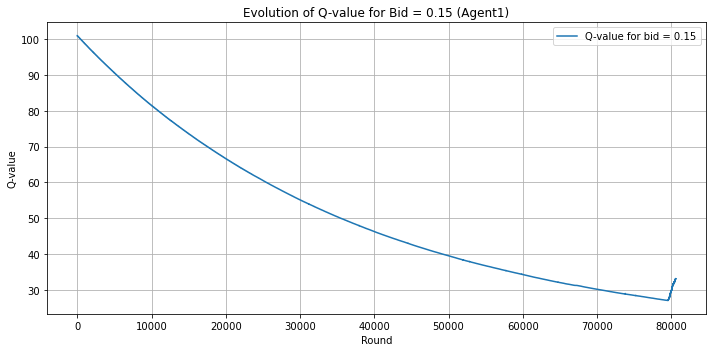

In [19]:
import matplotlib.pyplot as plt

bidder_name = "Agent1"
bid_index = 2

q_trajectory = extract_q_trajectory(history_FPA, bidder_name, bid_index)

plt.figure(figsize=(10, 5))
plt.plot(q_trajectory, label="Q-value for bid = 0.15")
plt.xlabel("Round")
plt.ylabel("Q-value")
plt.title("Evolution of Q-value for Bid = 0.15 (Agent1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Now the evolution of the q-value associated to another bid.

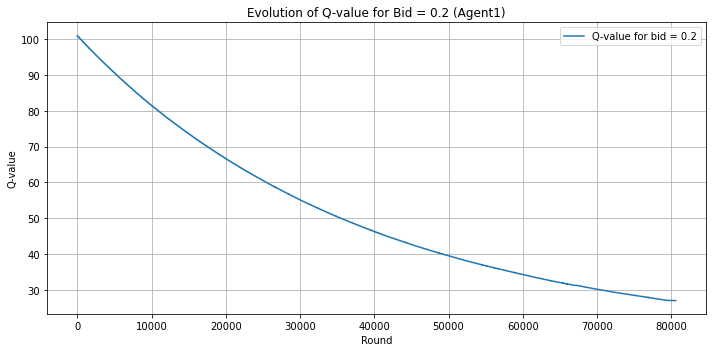

In [22]:
bid_index = 3

q_trajectory = extract_q_trajectory(history_FPA, bidder_name, bid_index)

plt.figure(figsize=(10, 5))
plt.plot(q_trajectory, label="Q-value for bid = 0.2")
plt.xlabel("Round")
plt.ylabel("Q-value")
plt.title("Evolution of Q-value for Bid = 0.2 (Agent1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Now let's look at just the final 5000 rounds to see the evolution in more detail.

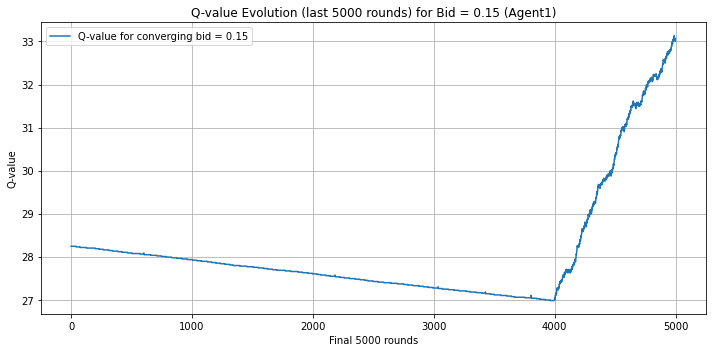

In [31]:
bid_index = 2
bidder_name = "Agent1"

q_trajectory = extract_q_trajectory(history_FPA, bidder_name, bid_index)

# Slice to last 5000 rounds
q_trajectory_recent = q_trajectory[-5000:]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(q_trajectory_recent, label=f"Q-value for converging bid = {0.15}")
plt.xlabel("Final 5000 rounds")
plt.ylabel("Q-value")
plt.title(f"Q-value Evolution (last 5000 rounds) for Bid = {0.15} ({bidder_name})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

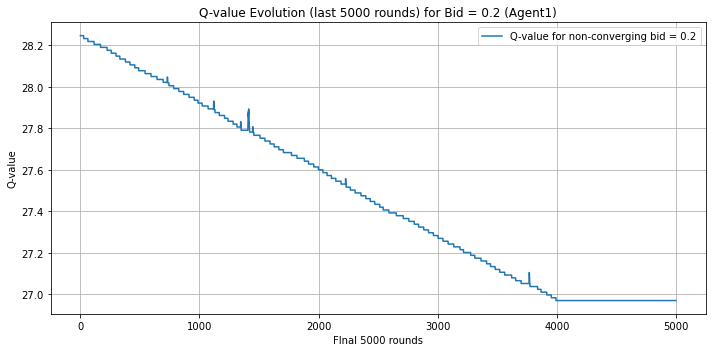

In [32]:
bid_index = 3
bidder_name = "Agent1"

q_trajectory = extract_q_trajectory(history_FPA, bidder_name, bid_index)

# Slice to last 5000 rounds
q_trajectory_recent = q_trajectory[-5000:]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(q_trajectory_recent, label=f"Q-value for non-converging bid = {0.2}")
plt.xlabel("FInal 5000 rounds")
plt.ylabel("Q-value")
plt.title(f"Q-value Evolution (last 5000 rounds) for Bid = {0.2} ({bidder_name})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

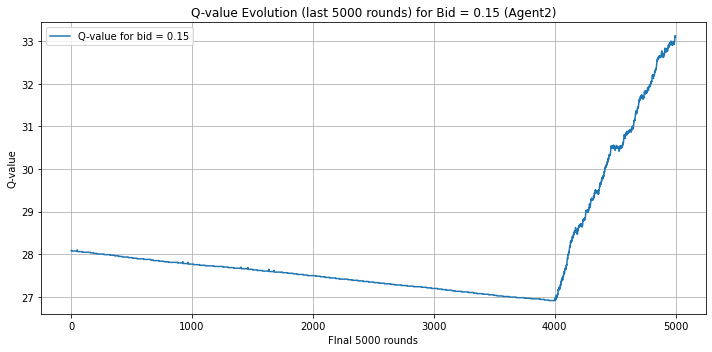

In [33]:
bid_index = 2
bidder_name = "Agent2"

q_trajectory = extract_q_trajectory(history_FPA, bidder_name, bid_index)

# Slice to last 5000 rounds
q_trajectory_recent = q_trajectory[-5000:]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(q_trajectory_recent, label=f"Q-value for bid = {0.15}")
plt.xlabel("FInal 5000 rounds")
plt.ylabel("Q-value")
plt.title(f"Q-value Evolution (last 5000 rounds) for Bid = {0.15} ({bidder_name})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### Q-value evolution for SPA:

Had winning bid 0.95 (has index 18).

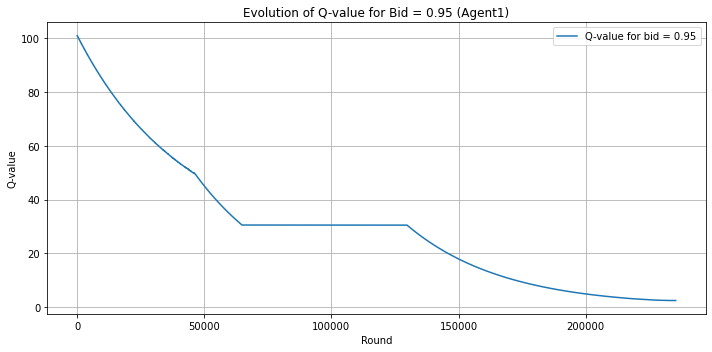

In [38]:
import matplotlib.pyplot as plt

bidder_name = "Agent1"
bid_index = 18

q_trajectory = extract_q_trajectory(history_SPA, bidder_name, bid_index)

plt.figure(figsize=(10, 5))
plt.plot(q_trajectory, label="Q-value for bid = 0.95")
plt.xlabel("Round")
plt.ylabel("Q-value")
plt.title("Evolution of Q-value for Bid = 0.95 (Agent1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

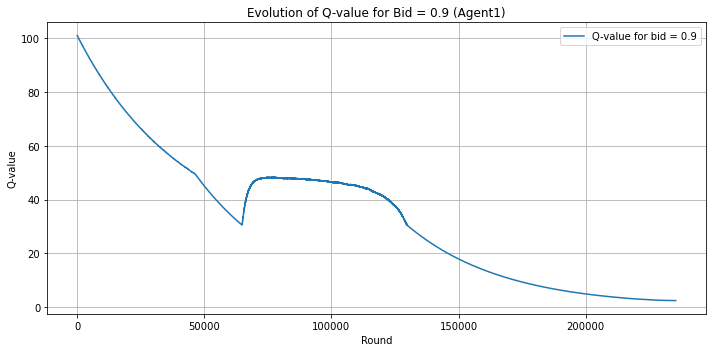

In [41]:
import matplotlib.pyplot as plt

bidder_name = "Agent1"
bid_index = 17

q_trajectory = extract_q_trajectory(history_SPA, bidder_name, bid_index)

plt.figure(figsize=(10, 5))
plt.plot(q_trajectory, label="Q-value for bid = 0.9")
plt.xlabel("Round")
plt.ylabel("Q-value")
plt.title("Evolution of Q-value for Bid = 0.9 (Agent1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

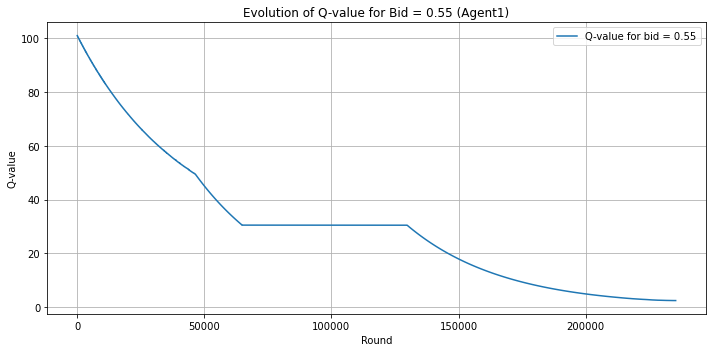

In [42]:
import matplotlib.pyplot as plt

bidder_name = "Agent1"
bid_index = 10

q_trajectory = extract_q_trajectory(history_SPA, bidder_name, bid_index)

plt.figure(figsize=(10, 5))
plt.plot(q_trajectory, label="Q-value for bid = 0.55")
plt.xlabel("Round")
plt.ylabel("Q-value")
plt.title("Evolution of Q-value for Bid = 0.55 (Agent1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()